# Introduction

**In this lecture, we will learn**
- basics of binary mathematical morphology,
- its most common operations like dilation, erosion, closing and opening,
- basics of grayscale morphology,
- and how to apply morphological techniques to process images.

**The lecture is based on**
- Chapter 7 "Morphological Filters" of  
  [\[Burger22\] Wilhelm Burger, Mark J. Burge: *Digital Image Processing: An Algorithmic Introduction (3rd edition)*](https://imagingbook.com/books/english-edition-hardcover/)
- Chapter 9 "Morphological Image Processing" of  
  [\[Gonzalez18\] Rafael C. Gonzalez, Richard E. Woods. *Digital Image Processing (4th edition)*](https://www.imageprocessingplace.com/)

In [1]:
from typing import Literal

import cv2 as cv
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import skimage

In [2]:
sns.set_theme(style='darkgrid')
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['image.cmap'] = 'viridis'
np.set_printoptions(threshold=20, edgeitems=10, linewidth=140, precision=3, suppress=True, formatter={'bool': lambda x: str(int(x))})

In [3]:
def imshow_grid(
    nrows: int | None = None,
    ncols: int | None = None,
    figsize: tuple[float, float] | None = None,
    cmap: str = 'gray',
    vmin: int | float | Literal['min'] = 0,
    vmax: int | float | Literal['dtype', 'max'] = 'dtype',
    grid: bool = False,
    colorbar: bool = True,
    interpolation: Literal['nearest', 'bilinear'] = 'bilinear',
    axis_off: bool = True,
    proportional: bool = True,
    **images,
) -> tuple[plt.Figure, np.ndarray]:
    if nrows is None:
        nrows = 1
    if ncols is None:
        ncols = -int(-len(images) // nrows)  # ceil
    if figsize is None:
        fig_size_y = nrows * plt.rcParams['figure.figsize'][1]
        fig_size_x = max(1, (ncols + 1) / 2) * plt.rcParams['figure.figsize'][0]
    else:
        fig_size_x, fig_size_y = figsize
    if proportional:
        if nrows > 1:
            raise ValueError
        gridspec_kw = {'width_ratios': [img.shape[1] for img in images.values()]}
    else:
        gridspec_kw = None
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_size_x, fig_size_y), layout='constrained', gridspec_kw=gridspec_kw)
    axes = np.atleast_1d(axes)
    im = None
    rgb_only = True
    for ax, (name, img) in zip(axes.flat, images.items()):
        _vmin = vmin
        if _vmin == 'min':
            _vmin = img.min()
        _vmax = vmax
        if _vmax == 'dtype':
            _vmax = np.iinfo(img.dtype).max if np.issubdtype(img.dtype, np.integer) else 1.0
        elif _vmax == 'max':
            _vmax = img.max()
        im = ax.imshow(img, cmap=cmap, vmin=_vmin, vmax=_vmax, interpolation=interpolation)
        ax.grid(grid)
        ax.set_title(name)
        if axis_off:
            ax.axis('off')
        if img.ndim < 3 or img.shape[2] != 3:
            rgb_only = False
    if colorbar and im is not None and not rgb_only:
        if ncols > nrows:
            orientation = 'horizontal'
        elif ncols == nrows:
            orientation = 'horizontal' if im.get_size()[1] > im.get_size()[0] else 'vertical'
        else:
            orientation = 'vertical'
        if vmin == 'min' or vmax == 'max':
            for ax in axes.flat[: len(images)]:
                fig.colorbar(ax.images[0], ax=ax, orientation=orientation, aspect=30)
        else:
            fig.colorbar(im, ax=axes, orientation=orientation, aspect=50)
    return fig, axes

In [4]:
def bwrender(
    img: np.ndarray,
    origin: tuple[int, int] | None = None,
    dpi: float | None = None,
    alpha_chnl: bool = False,
    ticks: bool = True,
) -> np.ndarray:
    h, w = img.shape

    if dpi is None:
        dpi = mpl.rcParams['figure.dpi']
    fig, ax = plt.subplots(figsize=(w, h), dpi=dpi)
    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(h - 0.5, -0.5)

    for i in range(h):
        for j in range(w):
            color = 'lightgray'
            if origin is not None and (i, j) == origin:
                color = 'lightcoral'  # red origin
            elif img[i, j] < 0:
                color = 'white'  # don't care
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=color, edgecolor='white', linewidth=2)
            ax.add_patch(rect)
            if img[i, j] < 0:
                ax.plot(j, i, marker='x', color='gray', markersize=48, markeredgewidth=1)
            if img[i, j] > 0:
                rect = plt.Rectangle((j - 0.3, i - 0.3), 0.6, 0.6, facecolor='black', edgecolor='black')
                ax.add_patch(rect)

    ax.grid(False)
    if ticks:
        ax.set_xticks(np.arange(w))
        ax.set_yticks(np.arange(h))
        ax.set_xticklabels(np.arange(w))
        ax.set_yticklabels(np.arange(h))
        ax.tick_params(top=False, right=False)
    else:
        ax.set_xticks([])
        ax.set_yticks([])
    ax.set_aspect('equal')

    # Render the figure
    fig.canvas.draw()
    img = np.asarray(fig.canvas.buffer_rgba())
    if not alpha_chnl:
        img = img[..., :3]  # drop alpha channel
    plt.close(fig)
    
    return img

In [5]:
def bwshow(
    img: np.ndarray,
    render: bool = True,
    origin: tuple[int, int] | None = None,
    ax: plt.Axes | None = None,
    dpi: float | None = 150,
) -> plt.Axes:
    if dpi is None:
        dpi = mpl.rcParams['figure.dpi']
    interp = 'nearest'
    if render and img.ndim == 2:
        img = bwrender(img, origin=origin, dpi=dpi)
        interp = 'bilinear'
    if ax is None:
        h, w = img.shape[:2]
        figsize = w / float(dpi), h / float(dpi)
        fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img, cmap='gray', interpolation=interp)
    ax.grid(False)
    ax.set_frame_on(False)
    ax.set_xticks([])
    ax.set_yticks([])
    # ax.set_xticklabels([])
    return ax

# Binary morphology

**Image as a point set**
- Mathematical morphology treats images as **sets of points**.
- In case of 2D binary images whose values are either 0 or 1 (background or foreground), the corresponding point set consists of all foreground coordinates, i.e. 
  $$
  Q_I = \{\bold{p} \mid I(\bold{p}) = 1 \}
  $$
  where
  - $I(m ,n) \in \{0, 1\}$ is the binary image,
  - $\bold{p} = (m, n)$ and $\bold{p} = \subseteq \mathbb{Z}^2$,
  - $Q_I$ is the equivalent set representation of $I$.

**Structuring element**
- Similarly to e.g. spatial filtering, most morphological operations are binary, i.e. they "filter" an image with some "kernel".
- In binary morphology, the kernel is called **SE**.
- Also similarly to spatial kernels, structuring elements have **origin** point that
  - defines the location of (0, 0),
  - which means all other foreground coordinates are defines with respect to it.

<figure class="image">
  <img src="../figures/morphology-point_sets.png" alt="" style="width: 6.4in; background: white"/>
  <figcaption>
    Binary image and structuring element as a sets of points in 2D. The red point denotes the origin.<br>
    Source: [Burger22], Fig. 7.6
  </figcaption>
</figure>

**Note**
- In the following, we're going to "overload" the notation and treat $I$ as either a 2D binary function or as a set of 2D points, depending on the context.

**Inversion (complement)**
- Inverting a binary image $I \rightarrow \bar{I}$ is equivalent to building the *complementary set*
  $$
  Q_{\bar{I}} = \bar{Q}_I = \{ \bold{p} \in \mathbb{Z}^2 \mid \bold{p} \notin Q_I \}
  $$

**Reflection**
- Reflection of a set $A$ is defined as
  $$
  A^* = \{ -\bold{p} \mid \bold{p} \in A \}
  $$

**Translation**
- Translation of a set $A$ by point $\bold{d} = (d_1, d_2)$ is defined as
  $$
  (A)_{\bold{q}} = \{ \bold{p} + \bold{q}, \bold{p} \in A \}
  $$
  where $\bold{q} = (u, v) \in \mathbb{Z}^2$.

In [6]:
def bounding_box(
    points: set[tuple[int, int]],
) -> tuple[int, int, int, int]:
    min_i = min(i for i, j in points)
    max_i = max(i for i, j in points)
    min_j = min(j for i, j in points)
    max_j = max(j for i, j in points)
    return min_i, min_j, max_i, max_j

In [7]:
def bw_to_set(
    img: np.ndarray,
    origin: tuple[int, int] = (0, 0),  # (y, x)
) -> set[tuple[int, int]]:
    """
    Convert a binary image to a set of coordinates of foreground pixels.
    """
    points = set()
    h, w = img.shape
    i0, j0 = origin
    for i in range(h):
        for j in range(w):
            if img[i, j]:
                points.add((i - i0, j - j0))
    return points

In [8]:
def set_to_bw(
    points: set[tuple[int, int]],
    origin: tuple[int, int] = (0, 0),
    shape: tuple[int, int] | None = None,
) -> np.ndarray:
    """
    Convert a set of coordinates of foreground pixels to a binary image.
    """
    if not points:
        if shape is None:
            shape = (1, 1)
        return np.zeros(shape, dtype=bool)
    if shape is None:
        _, _, max_i, max_j = bounding_box(points)
        shape = (max_i, max_j)
    i0, j0 = origin
    img = np.zeros(shape, dtype=bool)
    for i, j in points:
        if 0 <= i + i0 < shape[0] and 0 <= j + j0 < shape[1]:
            img[i + i0, j + j0] = True
    return img

In [9]:
def set_translate(
    points: set[tuple[int, int]],
    offset: tuple[int, int],
) -> set[tuple[int, int]]:
    """
    Translate a set of coordinates of foreground pixels.
    """
    return {(i + offset[0], j + offset[1]) for i, j in points}

In [10]:
toy_bw = np.array(
    [
        [1, 1, 1, 0],
        [1, 0, 1, 0],
        [0, 1, 1, 0],
        [0, 1, 0, 0],
        [0, 1, 0, 0],
    ],
    dtype=bool,
)
toy_bw

array([[1, 1, 1, 0],
       [1, 0, 1, 0],
       [0, 1, 1, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0]])

In [11]:
toy_set = bw_to_set(toy_bw)
toy_set

{(0, 0), (0, 1), (0, 2), (1, 0), (1, 2), (2, 1), (2, 2), (3, 1), (4, 1)}

In [12]:
set_to_bw(toy_set, shape=toy_bw.shape)

array([[1, 1, 1, 0],
       [1, 0, 1, 0],
       [0, 1, 1, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0]])

## Binary dilation

- Dilation is one of the two fundamental operations in morphology - the other being erosion.
- Dilation refers to the concept of region "growing".
- In terms of sets it is defined as  
  $$
  I \oplus H = \{ \bold{p} + \bold{q} \mid \bold{p} \in I, \bold{q} \in H \}
  $$

<figure class="image">
  <img src="../figures/morphology-dilation.png" alt="" style="width: 6.4in; background: white"/>
  <figcaption>
    Dilation example.<br>
    Source: [Burger22], Fig. 7.7
  </figcaption>
</figure>

In [13]:
def set_dilate(
    foreground: set[tuple[int, int]],
    strel: set[tuple[int, int]],
) -> set[tuple[int, int]]:
    dilation = set()
    for i, j in foreground:
        for m, n in strel:
            dilation.add((i + m, j + n))
    return dilation

In [14]:
toy_strel_bw = np.array([[1, 1]], dtype=bool)
toy_strel_set = bw_to_set(toy_strel_bw, origin=(0, 0))
toy_strel_bw, toy_strel_set

(array([[1, 1]]), {(0, 0), (0, 1)})

In [15]:
toy_dil_set = set_dilate(toy_set, toy_strel_set)  # perform dilation on sets
toy_dil_bw = set_to_bw(toy_dil_set, shape=toy_bw.shape)  # convert dilated set back to binary image
toy_dil_bw

array([[1, 1, 1, 1],
       [1, 1, 1, 1],
       [0, 1, 1, 1],
       [0, 1, 1, 0],
       [0, 1, 1, 0]])

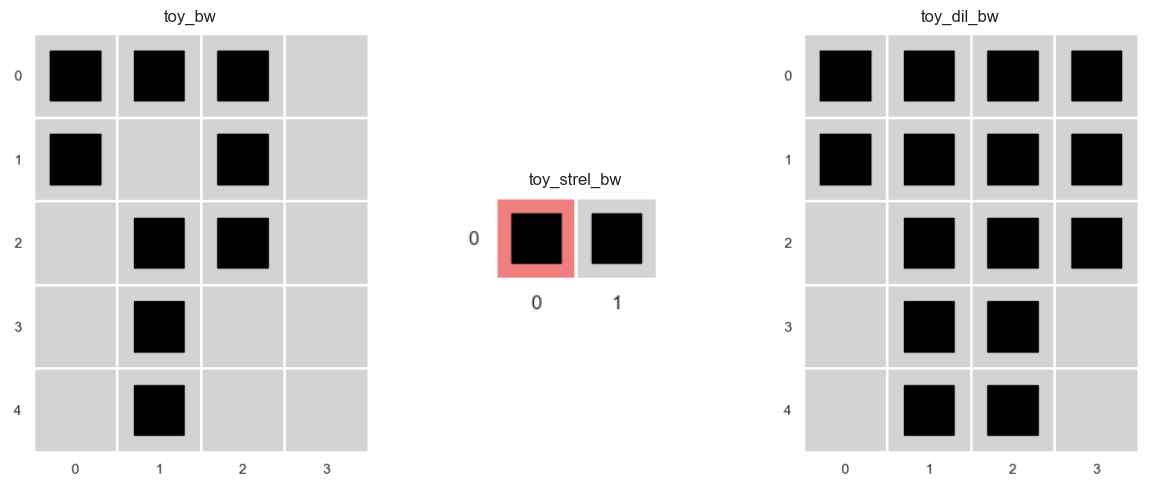

In [16]:
imshow_grid(toy_bw=bwrender(toy_bw), toy_strel_bw=bwrender(toy_strel_bw, origin=(0, 0)), toy_dil_bw=bwrender(toy_dil_bw), proportional=True);

In [17]:
def bw_dilate(
    img: np.ndarray,
    strel: np.ndarray,
    origin: tuple[int, int] | None = None,
) -> np.ndarray:
    if origin is None:
        origin = (strel.shape[0] // 2, strel.shape[1] // 2)
    foreground = bw_to_set(img)
    strel_set = bw_to_set(strel, origin=origin)
    dilation_set = set_dilate(foreground, strel_set)
    dilation_img = set_to_bw(dilation_set, shape=img.shape)
    return dilation_img

In [18]:
toy_dil_bw = bw_dilate(toy_bw, toy_strel_bw, origin=(0, 0))
toy_dil_bw.shape, toy_dil_bw.dtype

((5, 4), dtype('bool'))

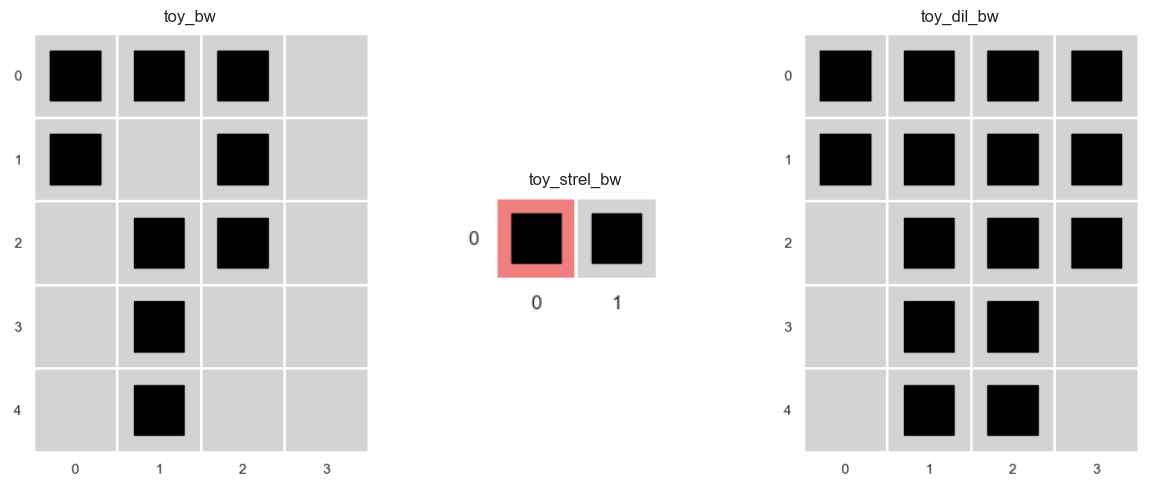

In [19]:
imshow_grid(toy_bw=bwrender(toy_bw), toy_strel_bw=bwrender(toy_strel_bw, origin=(0, 0)), toy_dil_bw=bwrender(toy_dil_bw), axis_off=True, proportional=True);

### A real world example of dilation

- Dilation can be used to fill holes or connect components that are close and almost touching.
- Let's look at example of an imperfect thresholding that leaves holes in the connected components.

In [20]:
coins_gray = skimage.io.imread('../data/coins.png', as_gray=True)
coins_bw = coins_gray < 0.45  # imperfect thresholding
coins_bw.shape, coins_bw.dtype

((480, 640), dtype('bool'))

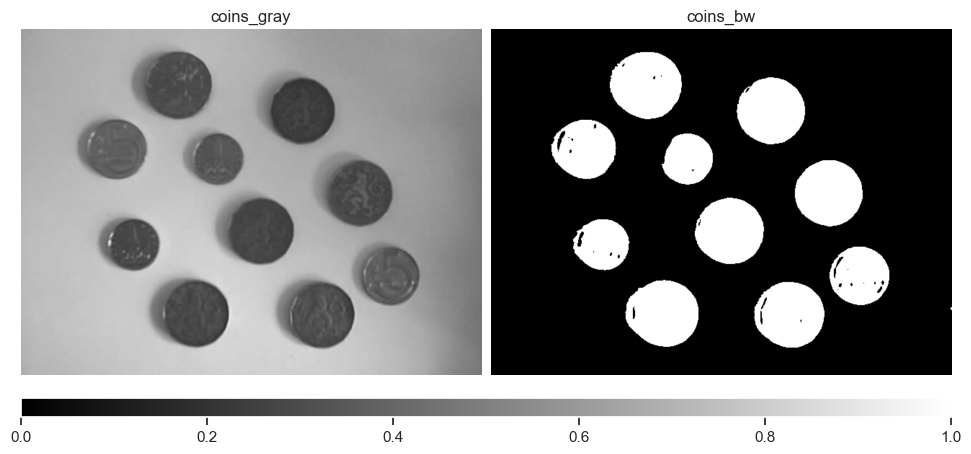

In [21]:
imshow_grid(coins_gray=coins_gray, coins_bw=coins_bw);

**Designing structuring element**
- In order to fill the holes in coins, we need sufficiently large SE - at least as big as the holes.
- Since the coins are round, we also want an *isotropic* SE. That way we'll not alter their shape too much.

In [ ]:
def disk(diameter: int) -> np.ndarray:
    """Create a disk-shaped SE."""
    radius = diameter // 2
    y, x = np.ogrid[-radius:diameter-radius, -radius:diameter-radius]
    strel = x**2 + y**2 <= radius**2
    return strel

In [23]:
coins_strel = disk(11)  # SE needs to be sufficiently large
coins_strel.shape, coins_strel.dtype

((11, 11), dtype('bool'))

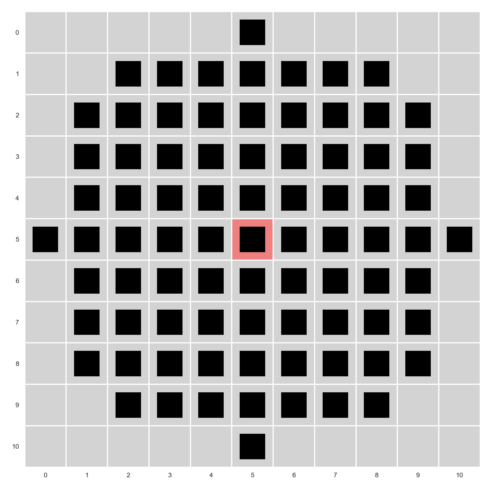

In [24]:
bwshow(coins_strel, origin=(5, 5), ax=plt.gca());

In [25]:
coins_dil = bw_dilate(coins_bw, coins_strel)
coins_dil.shape, coins_dil.dtype

((480, 640), dtype('bool'))

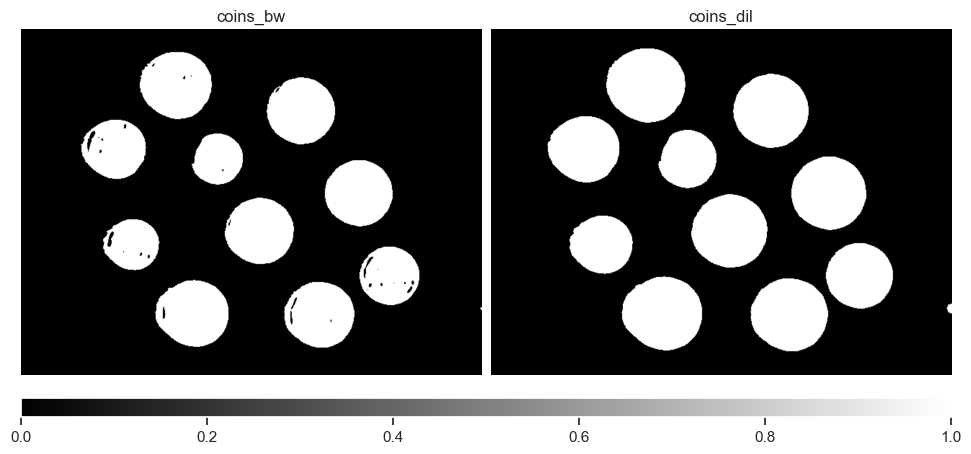

In [26]:
imshow_grid(coins_bw=coins_bw, coins_dil=coins_dil, vmax=1);

## Binary erosion

- Notice in the coins example above that
  - although the dilation closed the holes,
  - it also expanded the coins themselves.
- If we wanted to reduce the coins to their original size, we could employ the other fundamental morphology operation: erosion.
- It is in some sense dual to dilation, i.e. it reduces objects in their size.
- Binary erosion is defined as
  $$
  I \ominus H = \{ \bold{p} \mid (H)_{\bold{p}} \subseteq I \}
  $$
  i.e. a set of all coordinates of A where foreground of B is fully contained within A.

<figure class="image">
  <img src="../figures/morphology-erosion.png" alt="" style="width: 6.4in; background: white"/>
  <figcaption>
    Erosion example.<br>
    Source: [Burger22], Fig. 7.8
  </figcaption>
</figure>

In [27]:
def set_erode(
    foreground: set[tuple[int, int]],
    strel: set[tuple[int, int]],
) -> set[tuple[int, int]]:
    erosion = set()
    i1f, j1f, i2f, j2f = bounding_box(foreground)
    i1s, j1s, i2s, j2s = bounding_box(strel)
    for i in range(i1f - i2s, i2f - i1s + 1):
        for j in range(j1f - j2s, j2f - j1s + 1):
            strel_translated = set_translate(strel, (i, j))
            if strel_translated.issubset(foreground):    
                erosion.add((i, j))
    return erosion

In [28]:
def bw_erode(
    img: np.ndarray,
    strel: np.ndarray,
    origin: tuple[int, int] | None = None,
) -> np.ndarray:
    if origin is None:
        origin = (strel.shape[0] // 2, strel.shape[1] // 2)
    foreground = bw_to_set(img)
    strel_set = bw_to_set(strel, origin=origin)
    erosion_set = set_erode(foreground, strel_set)
    erosion_img = set_to_bw(erosion_set, shape=img.shape)
    return erosion_img

In [29]:
toy_ero_bw = bw_erode(toy_bw, toy_strel_bw, origin=(0, 0))
toy_ero_bw.shape, toy_ero_bw.dtype

((5, 4), dtype('bool'))

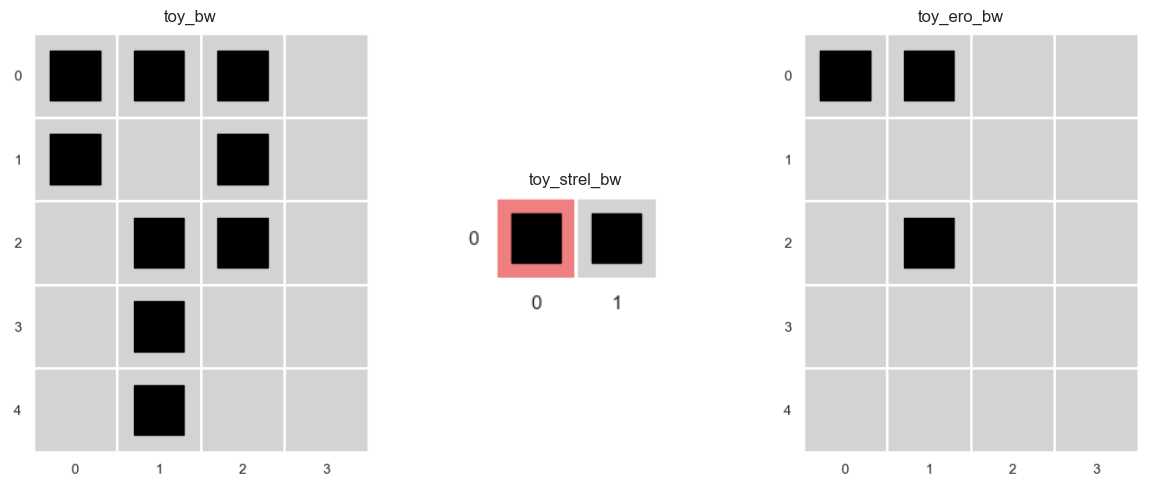

In [30]:
imshow_grid(toy_bw=bwrender(toy_bw), toy_strel_bw=bwrender(toy_strel_bw, origin=(0, 0)), toy_ero_bw=bwrender(toy_ero_bw), axis_off=True, proportional=True);

### Erosion applied to the coins image

- We can apply the erosion operation to restore the original size of the coins.
- We'll reuse the same SE, because we want to "peel off" as much as we added during the dilation.

In [31]:
coins_dil_ero_bw = bw_erode(coins_dil, coins_strel)
coins_dil_ero_bw.shape, coins_dil_ero_bw.dtype

((480, 640), dtype('bool'))

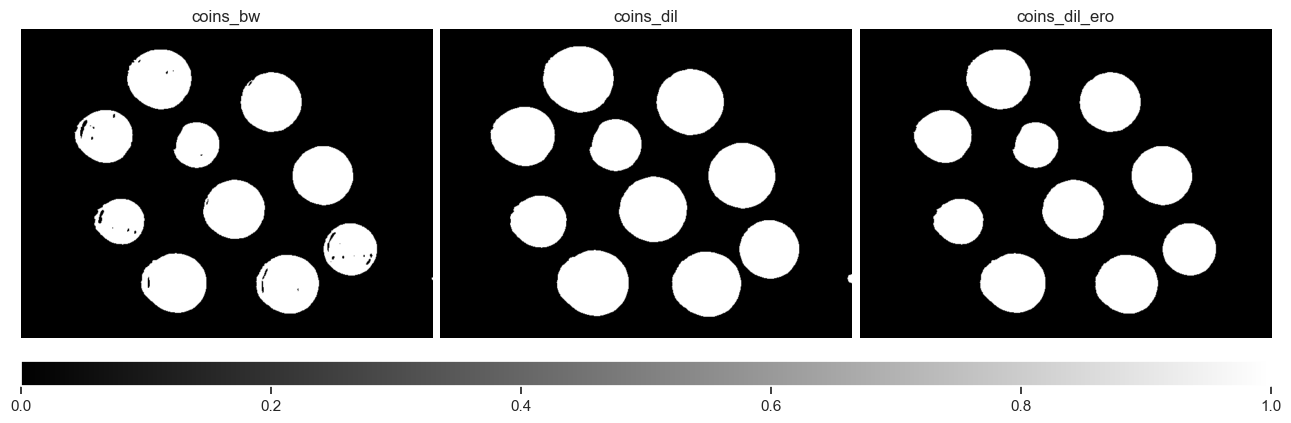

In [32]:
imshow_grid(coins_bw=coins_bw, coins_dil=coins_dil, coins_dil_ero=coins_dil_ero_bw, axis_off=True);

## Properties of dilation and erosion

**Commutativity**
- The dilation is commutative, i.e.
  $$
  I \oplus H = H \oplus I
  $$
- The erosion is *not* commutative, i.e.
  $$
  I \ominus H \ne H \ominus I
  $$

**Associativity**
- Dilation is also associative, i.e.
  $$
  (I \oplus H_1) \oplus H_2 = I \oplus (H_1 \oplus H_2)
  $$
- Associativity of the dilation can be used
  - to precompute a composite dilation SE and only perform the operation once,
  - or vice versa to decompose dilation with a large SE into multiple but more efficient steps.

**Neutral element**
- There is also a neutral SE $\delta = {(0, 0)}$ for which
  $$
  I \oplus \delta = I
  $$

**Dilation and erosion duality**
- Although dilation and erosion are *not* exact inverses of each other, they are *dual operations*, meaning  
  $$
  I \oplus H = \overline{ \bar{I} \ominus H^* }
  $$
  where
  - $\bar{X}$ denotes inversion,
  - $H^*$ denotes reflection.  
  That is dilation of the foreground can be achieved by erosion of the background and taking the inverse.
- It also holds vice-versa  
  $$
  \bar{I} \ominus H = \overline{ I \oplus H^* }
  $$  
  i.e. erosion of the foreground is equivalent to dilation of the background and taking the inverse.

<figure class="image">
  <img src="../figures/morphology-duality.png" alt="" style="width: 6.4in; background: white"/>
  <figcaption>
    Implementing erosion via dilation.<br>
    Source: [Burger22], Fig. 7.9
  </figcaption>
</figure>

## Binary closing

- What we just did with the coins, i.e. **dilation followed by erosion** using the same SE, is called **closing**  
  $$
  I \bullet H = (I \oplus H) \ominus H
  $$
- It is an example of a **composite** morphology operation, performing two fundamental ones in a particular order.
- We may notice that the dilation-erosion sequence first succesfully closed the holes and then restored the resulting objects to their original size (which obviously did not reintroduce the holes).

In [33]:
def bw_close(
    img: np.ndarray,
    strel: np.ndarray,
    origin: tuple[int, int] | None = None,
) -> np.ndarray:
    dilated = bw_dilate(img, strel, origin=origin)
    closed = bw_erode(dilated, strel, origin=origin)
    return closed

In [34]:
coins_clo_bw = bw_close(coins_bw, coins_strel)
coins_clo_bw.shape, coins_clo_bw.dtype

((480, 640), dtype('bool'))

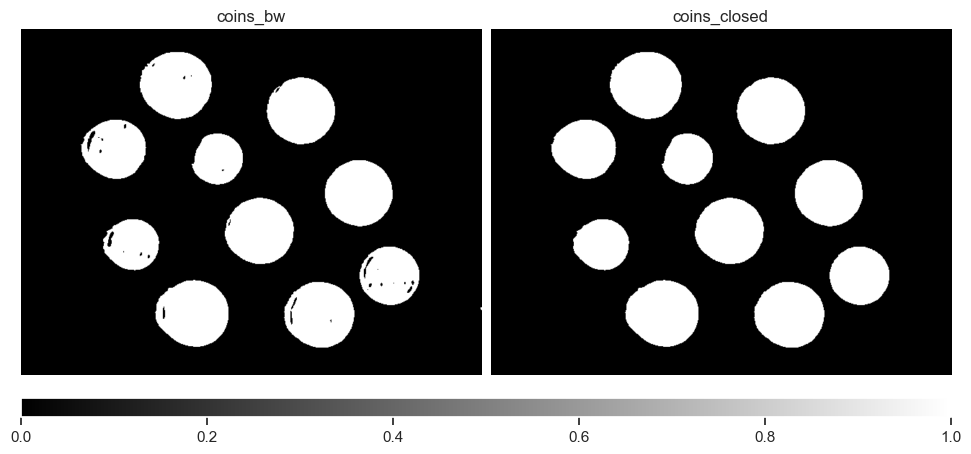

In [35]:
imshow_grid(coins_bw=coins_bw, coins_closed=coins_clo_bw);

## Binary opening

- Another commonly used composite operation is **erosion followed by dilation**, i.e. the opening  
  $$
  I \circ H = (I \ominus H) \oplus H
  $$
- Erosion is useful e.g. for getting rid of small objects that basically constitute a noise after an imperfect thresholding.

In [36]:
def bw_open(
    img: np.ndarray,
    strel: np.ndarray,
    origin: tuple[int, int] | None = None,
) -> np.ndarray:
    eroded = bw_erode(img, strel, origin=origin)
    opened = bw_dilate(eroded, strel, origin=origin)
    return opened

In [37]:
rice_gray = skimage.io.imread('../data/rice.png', as_gray=True)
rice_bw = rice_gray > 0.46  # imperfect thresholding
rice_bw.shape, rice_bw.dtype

((256, 256), dtype('bool'))

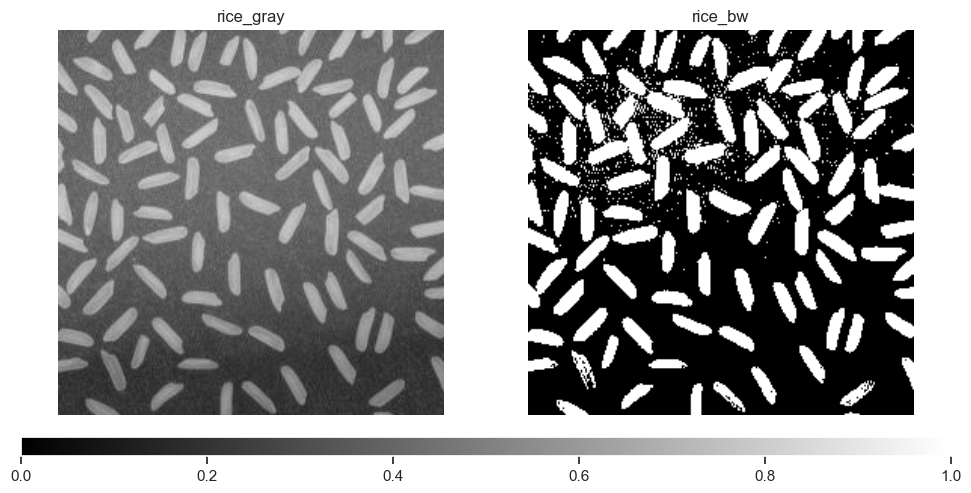

In [38]:
imshow_grid(rice_gray=rice_gray, rice_bw=rice_bw);

- Since we only want to remove small objects, we will create a small SE so that the erosion doesn't "eat away" objects of interest - the rice grains.

In [39]:
rice_strel = disk(3)
rice_opn = bw_open(rice_bw, rice_strel)
rice_opn.shape, rice_opn.dtype

((256, 256), dtype('bool'))

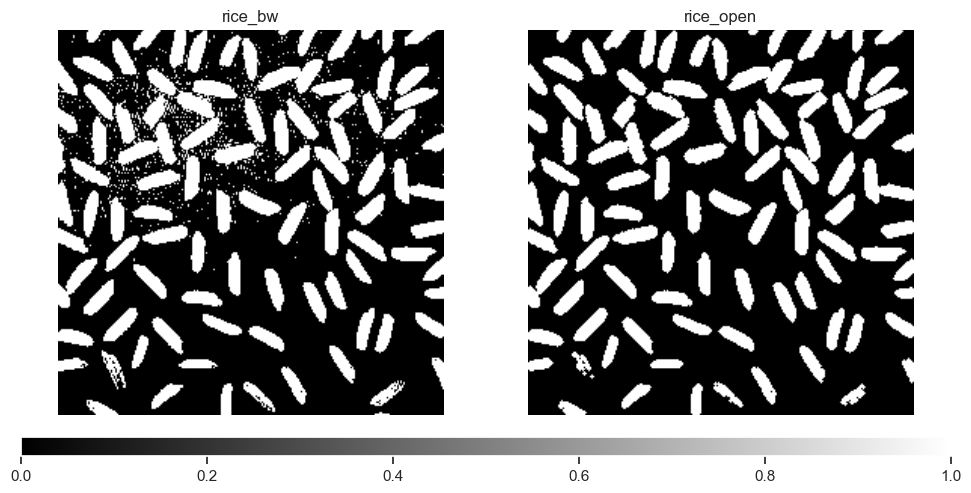

In [40]:
imshow_grid(rice_bw=rice_bw, rice_open=rice_opn);

## Properties of closing and opening

- Both operations are *idempotent*, i.e. any subsequent application of the same operation no longer changes the result.
- Also, similarly to dilation and erosion, closing and opening are dual, i.e.  
  $$
  I \circ H = \overline{ \bar{I} \bullet H } \\
  I \bullet H = \overline{ \bar{I} \circ H }
  $$

## Boundary extraction

- We can obtain object's border pixels by first eroding and then subtracting from the original binary image, i.e.  
  $$
  \beta(I) = I - (I \ominus H)
  $$
- Since we usually want single pixel wide border, we only use the smallest *isotropic*-ish SE possible, i.e. `disk(3)`, which is a 3x3 cross.

In [41]:
def bw_boundary(
    bw: np.ndarray,
    strel: np.ndarray,
    origin: tuple[int, int] | None = None,
) -> np.ndarray:
    eroded = bw_erode(bw, strel, origin=origin)
    # To be consistent with the morphological definition, we should
    # 1. convert both `bw` and `eroded` to sets of 2D points
    # 2. then subtract the sets,
    # 3. and then convert back to a binary image.
    # Instead, we can use bitwise and negation to achieve the same result more efficiently, since A - B = A & ~B.
    boundary = bw & ~eroded
    return boundary

In [42]:
coins_bnd = bw_boundary(coins_clo_bw, disk(3))
coins_bnd.shape, coins_bnd.dtype

((480, 640), dtype('bool'))

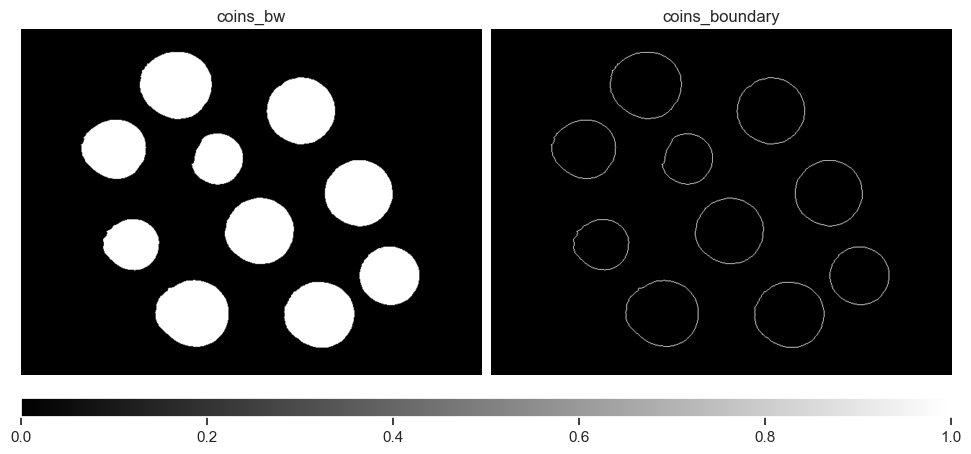

In [43]:
imshow_grid(coins_bw=coins_clo_bw, coins_boundary=coins_bnd, interpolation='bilinear');

## Hit-or-miss transformation (HMT)

- Hit-or-miss transformation acts a basic morphological shape detector.
- Defined as a set operation, it uses *two* structuring elements
  - $H_\text{fg}$ representing a foreground pattern,
  - $H_\text{bg}$ representing a background pattern.
- It is defined as  
  $$
  \begin{align*}
    I \circledast (H_\text{fg}, H_\text{bg})
    & = \left\{ \bold{p} \mid (H_\text{fg})_\bold{p} \subseteq I, (H_\text{bg})_\bold{p} \subseteq \bar{I} \right\} \\
    & = (I \ominus H_\text{fg}) \cap (\bar{I} \ominus H_\text{bg})
  \end{align*}
  $$
- Intuitively, when treating both $I$ and $H$ as a 2D binary images, HMT finds locations where $H$ is equal to $I$ in both zeros and ones (foreground and background).
- This is where it differs from erosion, which only searches for the foreground pixels.

In [44]:
def bw_hit_or_miss(
    img: np.ndarray,
    strel_fg: np.ndarray,
    strel_bg: np.ndarray,
    origin: tuple[int, int] | None = None,
) -> np.ndarray:
    eroded_fg = bw_erode(img, strel_fg, origin=origin)
    eroded_bg = bw_erode(~img, strel_bg, origin=origin)
    hit_or_miss = eroded_fg & eroded_bg
    return hit_or_miss

In [45]:
toy_hmt_strel_fg_bw = np.array([[0, 1], [0, 1]], dtype=bool)
toy_hmt_strel_bg_bw = np.array([[0, 0], [1, 0]], dtype=bool)
toy_hmt_strel_fg_bw, toy_hmt_strel_bg_bw

(array([[0, 1],
        [0, 1]]),
 array([[0, 0],
        [1, 0]]))

In [46]:
toy_hmt_bw = bw_hit_or_miss(toy_bw, toy_hmt_strel_fg_bw, toy_hmt_strel_bg_bw, origin=(0, 0))
toy_hmt_bw.shape, toy_hmt_bw.dtype

((5, 4), dtype('bool'))

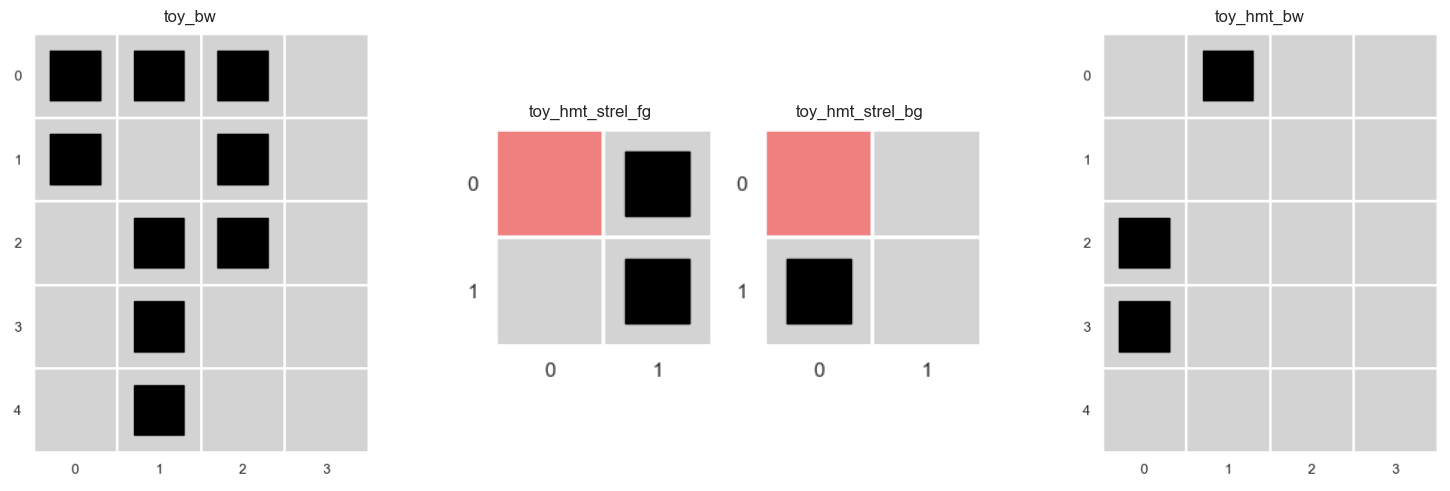

In [47]:
imshow_grid(
    toy_bw=bwrender(toy_bw),
    toy_hmt_strel_fg=bwrender(toy_hmt_strel_fg_bw, origin=(0, 0)),
    toy_hmt_strel_bg=bwrender(toy_hmt_strel_bg_bw, origin=(0, 0)),
    toy_hmt_bw=bwrender(toy_hmt_bw),
    axis_off=True,
    proportional=True,
);

### Hit-or-miss using single structuring element

- As we shall see in a bit, morphological operators are often implemented as a direct 2D array processing without regard to their formal set theory definitions.
- One example is that HMT corresponds to simple pattern matching, i.e. HMT finds locations where local neighborhood looks exactly like a "template" structuring element, *including both foreground and background pixels*.
- In order to specify non-rectanglar template shapes, we could add "don't care" values, e.g. -1, that wouldn't be subject to comparison.

In [48]:
def bw_hit_or_miss1(
    img: np.ndarray,
    strel: np.ndarray,
    origin: tuple[int, int] | None = None,
) -> np.ndarray:
    M, N = img.shape
    K, L = strel.shape
    i0, j0 = origin if origin is not None else (K // 2, L // 2)
    mask = strel >= 0  # ignore "don't care" pixels
    hmt = np.zeros_like(img)
    for i in range(M - K + 1):
        for j in range(N - L + 1):
            wnd = img[i : i + K, j : j + L]  # extract window
            if np.all(wnd[mask] == strel[mask]):  # compare only foreground and background pixels
                hmt[i + i0, j + j0] = True
    return hmt

In [49]:
toy_hmt_strel1 = np.array([[ -1, 1], [0, 1]], dtype=int)
toy_hmt_strel1

array([[-1,  1],
       [ 0,  1]])

In [50]:
toy_hmt_bw1 = bw_hit_or_miss1(toy_bw, toy_hmt_strel1, origin=(0, 0))
toy_hmt_bw1.shape, toy_hmt_bw1.dtype

((5, 4), dtype('bool'))

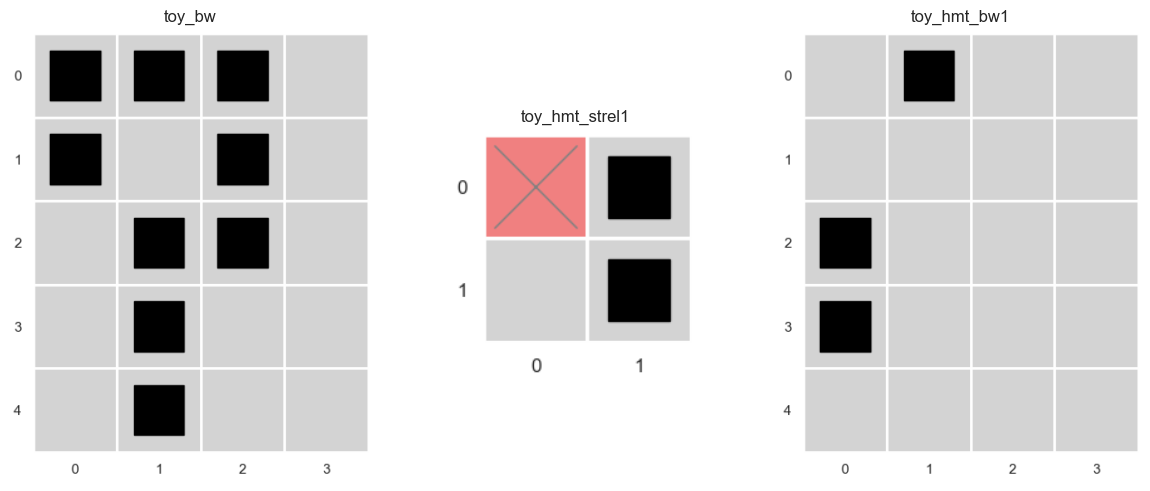

In [51]:
imshow_grid(toy_bw=bwrender(toy_bw), toy_hmt_strel1=bwrender(toy_hmt_strel1, origin=(0, 0)), toy_hmt_bw1=bwrender(toy_hmt_bw1), axis_off=True, proportional=True);

## Thinning and skeletonization

- Thinning refers to "peeling pixels off" of objects.
- It is,
  - similar to erosion in that it reduces object's size,
  - but in contrast to erosion it *never causes a breakage of an object into two*.
- Skeletonization is then reduction of objects to the minimal possible point count, i.e. a skeleton, such that their topology does not change, i.e. the number connected components in the binary image stays the same.
- Skeletonization is an iterative morphological operation.
- *One iteration* of thinning is defined as  
  $$
  I \otimes H = I - (I \circledast H)
  $$
  where
  - $\circledast$ denotes the hit-or-miss transform.
- The HMT marks pixels for removal, the subtraction then removes them.
- In order to reduce objects isotropically, typically a sequence of 8 particular structuring elements $(H_1, \ldots, H_8)$ is applied, each one checking for an edge or a corner in specific orientation:    
  $$
  H_1 = \begin{bmatrix}
    0 & 0 & 0 \\
      & 1 &   \\
    1 & 1 & 1 \\
  \end{bmatrix},
  \qquad
  H_2 = \begin{bmatrix}
      & 0 & 0 \\
    1 & 1 & 0 \\
    1 & 1 &   \\
  \end{bmatrix},
  \qquad
  H_3 = \begin{bmatrix}
    1 &   & 0 \\
    1 & 1 & 0 \\
    1 &   & 0 \\
  \end{bmatrix},
  \qquad
  \ldots ,
  \qquad
  H_8 = \begin{bmatrix}
    0 & 0 &   \\
    0 & 1 & 1 \\
      & 1 & 1 \\
  \end{bmatrix},
  $$
  where
  - "1" means foreground pixels,
  - "0" means" background pixels,
  - empty field denotes "don't care" pixels,
  - origin point is in the middle.
- We can see that
  - HMT using $H_1$ marks bottom edge pixels for removal, which we remove by the subtraction,
  - then HMT using $H_2$ marks bottom left corner pixels for removal, which we again remove,
  - and so on.
- We then repeat the whole octet again until convergence, that is until no more pixels can be removed and we're left with objects' skeletons
  $$
  I_{t+1} = I_t \otimes (H_1, \ldots, H_8)
  $$
- There are multiple algorithms to achieve skeletonization, with the above procedure being just one (rather inefficient) example. One efficient and commonly used method is due to [Zhang and Suen](https://dl.acm.org/doi/pdf/10.1145/357994.358023).

In [52]:
def bw_thin_once(
    img: np.ndarray,
    strel: np.ndarray,
    origin: tuple[int, int] | None = None,
) -> np.ndarray:
    hmt = bw_hit_or_miss1(img, strel, origin=origin)
    thinned = img & ~hmt
    return thinned

In [53]:
def bw_skeletonize(
    img: np.ndarray,
    strels: np.ndarray | None = None,
    origin: tuple[int, int] | None = None,
    max_iters: int = 20,
) -> np.ndarray:
    if strels is None:
        strel1 = np.array(
            [[ 0,  0,  0],
             [-1,  1, -1],
             [ 1,  1,  1]]
        )
        strel2 = np.array(
            [[-1,  0,  0],
             [ 1,  1,  0],
             [ 1,  1, -1]]
        )
        strels = np.stack([
            np.rot90(strel1, k) for k in range(4)
        ] + [
            np.rot90(strel2, k) for k in range(4)
        ])
    n_iters = 0
    skel = img.copy()
    while True:
        prev_skel = skel.copy()
        for strel in strels:
            skel = bw_thin_once(skel, strel, origin=origin)
        if np.array_equal(skel, prev_skel):
            break
        n_iters += 1
        if max_iters > 0 and n_iters >= max_iters:
            break
    return skel

In [54]:
shapes_bw = skimage.io.imread('../data/shapes.png', as_gray=True) < 0.5
shapes_bw.shape, shapes_bw.dtype

((128, 113), dtype('bool'))

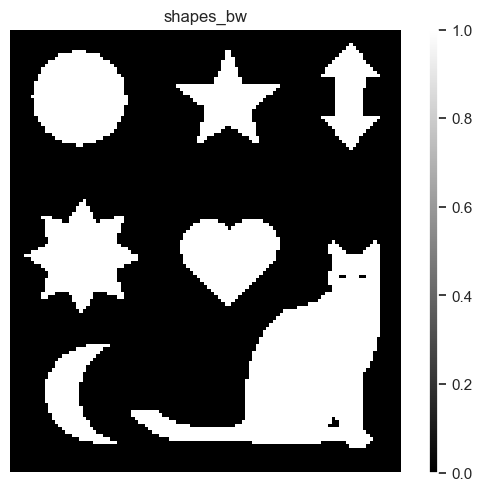

In [55]:
imshow_grid(shapes_bw=shapes_bw, axis_off=True, interpolation='nearest');

In [56]:
# Warning: long computation time
shapes_skel_bws = [shapes_bw]
for _ in range(4):
    shapes_skel_bws.append(bw_skeletonize(shapes_skel_bws[-1], max_iters=5))
shapes_skel_bws[0].shape, shapes_skel_bws[0].dtype

((128, 113), dtype('bool'))

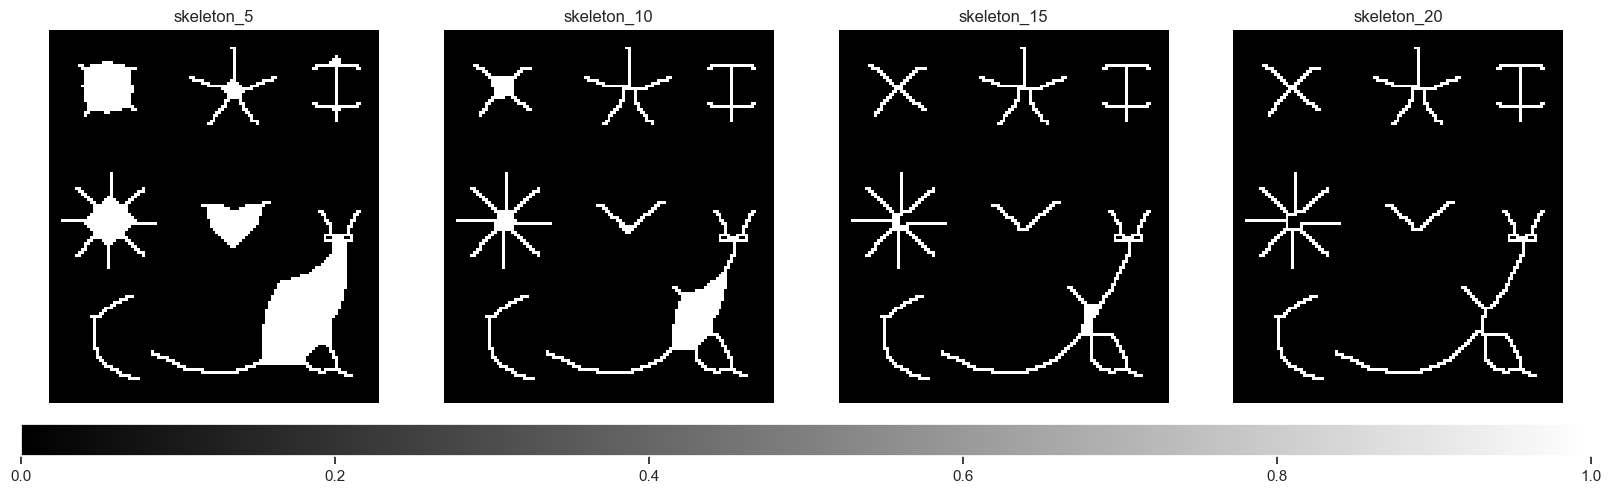

In [57]:
imshow_grid(**{f'skeleton_{5 * (i + 1)}': img for i, img in enumerate(shapes_skel_bws[1:])}, axis_off=True, interpolation='nearest');

## Morphological reconstruction

- Morphologial reconstruction is an iterative process involving *two* images:
  - *marker* that serves as a starting point for the reconstruction,
  - *mask* that **conditions** the reconstruction.
- The reconstruction *iteratively* "grows" the marker image (typically via dilation) and after each iteration, the result is constrained by the mask.

In [58]:
def bw_reconstruct_dilate(
    marker: np.ndarray,
    mask: np.ndarray,
    strel: np.ndarray | None = None,
    origin: tuple[int, int] | None = None,
    max_iters: int = 0,
) -> np.ndarray:
    if strel is None:
        strel = disk(3)
    reconstructed = marker.copy()
    iters = 0
    while True:
        prev_reconstructed = reconstructed.copy()
        dilated = bw_dilate(reconstructed, strel, origin=origin)
        reconstructed = dilated & mask  # conditional dilation
        iters += 1
        if (max_iters > 0 and iters >= max_iters) or np.array_equal(reconstructed, prev_reconstructed):
            break
    return reconstructed

### Semi-supervised hole filling using dilation by reconstruction

- Let's say we have an image $I$ showing objects with holes and we want to fill *some* of them.
- *We will mark which holes we want to fill* e.g. as a single pixel set to "1"  
  $$
  I_0 = \begin{cases}
    1 & \text{if } (x, y) \text{ is in a hole we want to fill } \\
    0 & \text{otherwise}
  \end{cases}
  $$
- Now, we can repeat the following until convergence (no more changes):
  $$
  I_{t+1} = (I_{t} \oplus H) \cap \bar{I}
  $$
  where
  $$
  H = \begin{bmatrix}
    0 & 1 & 0 \\
    1 & 1 & 1 \\
    0 & 1 & 0 \\
  \end{bmatrix}
  $$
- That is we perform dilation in all directions by one pixel, but using the set intersection we don't let it "spill over" the object's boundaries into the background.
- In other words, complement $\bar{I}$ of the original image $I$ serves as the mask that **conditions** the dilation on the foreground pixels (or object's boundary).
- After $T$ iterations, the the image with the marked holes filled is obtained as $I_T \cup I$.

<figure class="image">
  <img src="../figures/morphology-supervised_hole_fill.png" alt="" style="width: 12.8in; background: white"/>
  <figcaption>
    Hole filling example.<br>
    Source: [Gonzalez18], Fig. 9.17
  </figcaption>
</figure>

In [59]:
def bw_fill_markers(
    img: np.ndarray,
    markers: np.ndarray,
    max_iters: int = 0,
) -> np.ndarray:
    filled = bw_reconstruct_dilate(markers, ~img, max_iters=max_iters)
    return filled | img

In [60]:
hollow_shapes_bw = skimage.io.imread('../data/shapes.png', as_gray=True) < 0.5
hollow_shapes_bw = bw_boundary(hollow_shapes_bw, disk(3))  # make sure shapes are hollow
hollow_shapes_bw.shape, hollow_shapes_bw.dtype

((128, 113), dtype('bool'))

In [61]:
markers = np.zeros_like(hollow_shapes_bw)
markers[100, 80] = True
markers[65, 62] = True
hollow_shapes_fill_bw = bw_fill_markers(hollow_shapes_bw, markers=markers)
hollow_shapes_fill_bw = hollow_shapes_fill_bw | hollow_shapes_bw  # add boundaries back
hollow_shapes_fill_bw.shape, hollow_shapes_fill_bw.dtype

((128, 113), dtype('bool'))

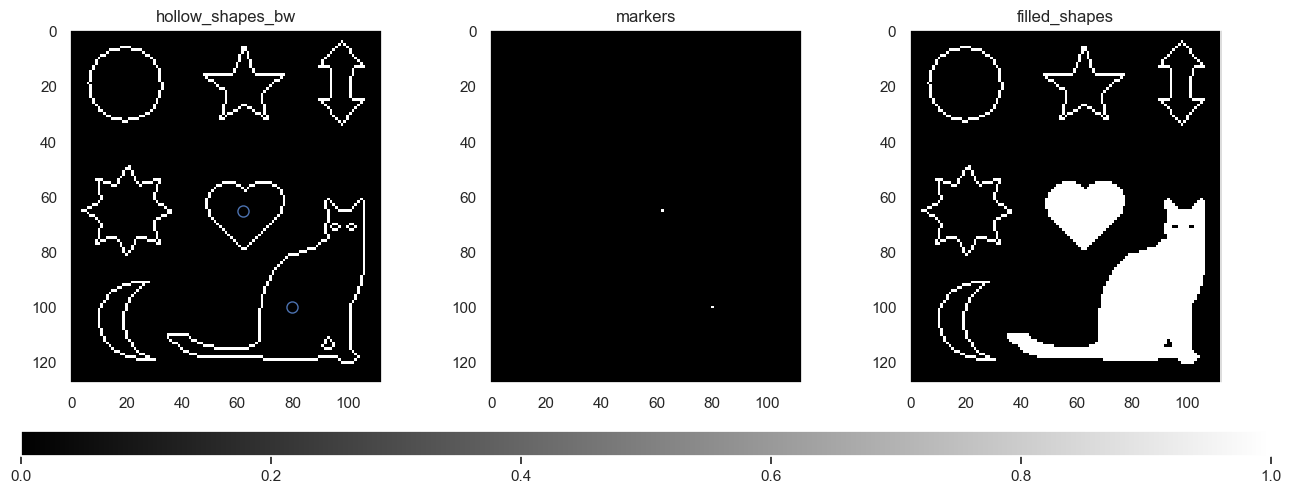

In [62]:
_, axes = imshow_grid(hollow_shapes_bw=hollow_shapes_bw, markers=markers, filled_shapes=hollow_shapes_fill_bw, interpolation='nearest', axis_off=False);
axes[0].plot(*np.argwhere(markers)[:, ::-1].T, 'o', markersize=8, markerfacecolor='none');

### Automatic hole filling

- We can tweak the idea to fill all holes without having to specify initial markers.
- We initialize the marker image $I_0$ as all zeros except for its borders, along which we set $\bar{I}$, i.e.  
  $$
  I_0 = \begin{cases}
    \overline{I(x, y)} & \text{if } (x, y) \text{ is on the border of } I \\
    0 & \text{otherwise}
  \end{cases}
  $$
- Again, we then dilate by reconstruction (the as the semi-supervised hole filling)
  $$
  I_{t+1} = (I_{t} \oplus H) \cap \bar{I}
  $$
- The final result is obtained by inverting the reconstruction result.

<figure class="image">
  <img src="../figures/morphology-automatic_hole_fill.png" alt="" style="width: 12.8in; background: white"/>
  <figcaption>
    Hole filling example.<br>
    Source: [Gonzalez18], Fig. 9.32
  </figcaption>
</figure>

In [63]:
def bw_fill(
    img: np.ndarray,
    max_iters: int = 0,
) -> np.ndarray:
    # Initialize border as the complement of img, other pixels as 0
    filled = ~img
    filled[1:-1, 1:-1] = False
    # Perform reconstruction by dilation on the complement image
    filled = bw_reconstruct_dilate(filled, ~img, max_iters=max_iters)
    return ~filled

In [64]:
hollow_shapes_bw = skimage.io.imread('../data/shapes.png', as_gray=True) < 0.5
hollow_shapes_bw = bw_boundary(hollow_shapes_bw, disk(3))  # make sure shapes are hollow
hollow_shapes_bw.shape, hollow_shapes_bw.dtype

((128, 113), dtype('bool'))

In [65]:
hollow_shapes_fill_bw = bw_fill(hollow_shapes_bw)
hollow_shapes_fill_bw = hollow_shapes_fill_bw | hollow_shapes_bw  # add boundaries back
hollow_shapes_fill_bw.shape, hollow_shapes_fill_bw.dtype

((128, 113), dtype('bool'))

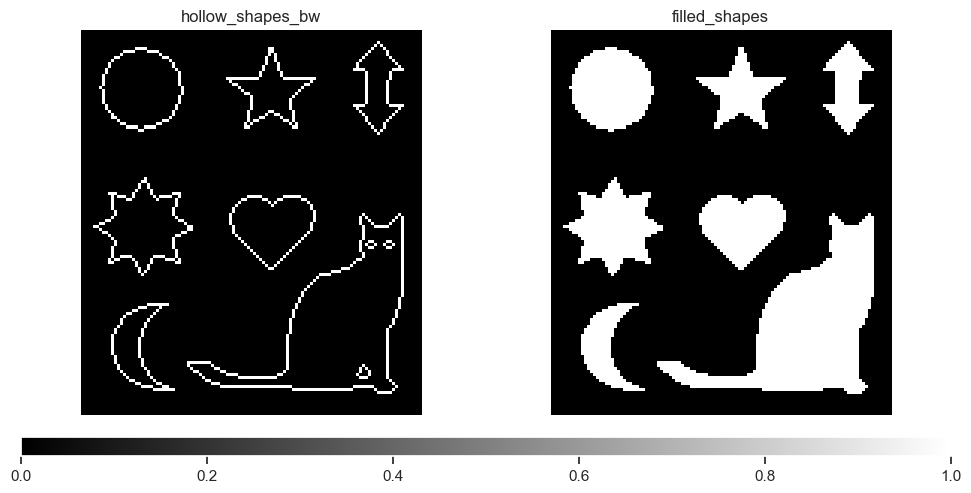

In [66]:
imshow_grid(hollow_shapes_bw=hollow_shapes_bw, filled_shapes=hollow_shapes_fill_bw, interpolation='nearest');

### Remove objects of specific shape using opening by reconstruction

- Let's look at an example from [Gonzalez18].
- We have an image of text and we want to extract all characters with a long vertical stroke.

In [67]:
text_bw = skimage.io.imread('../data/dip3_0929_text.tif', as_gray=True)
text_bw = text_bw > 0.5
text_bw.shape, text_bw.dtype

((918, 2018), dtype('bool'))

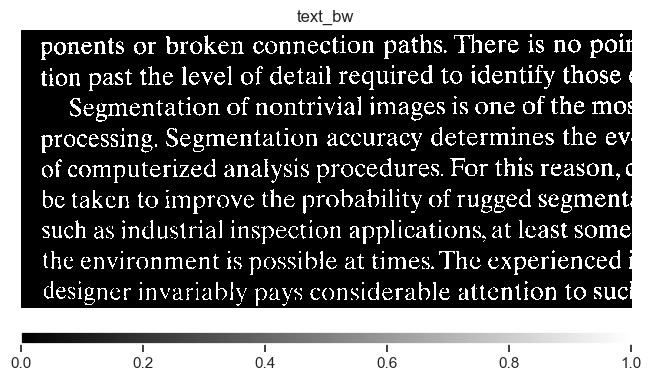

In [68]:
imshow_grid(text_bw=text_bw, interpolation='nearest', axis_off=True);

- The average height of the characters in the image is 51 pixels.
- This means we can remove all except the tall characters by erosion with a SE of shape 51x1.
- We then use this **erosion as a starting point (marker)** for **dilation by reconstruction** and condition on the original image, i.e.  
  $$
  I_{t+1} = (I_t \oplus H) \cap I
  $$
- So, to reiterate, **opening by reconstruction** is  
  1. erode to create the marker (typically one iteration),
  2. dilate by reconstruction (typically many iterations).
- Note that the SE used for the erosion step to create the markers is task specific, while the dilation SE usually is the 3x3 cross or square and defines the pixel connectivity.
- Also, we may view the task of extracting tall characters as **finding connected components** that are touching the specified markers.

In [69]:
text_markers = bw_erode(text_bw, np.ones((51, 1), dtype=bool))
text_markers.shape, text_markers.dtype

((918, 2018), dtype('bool'))

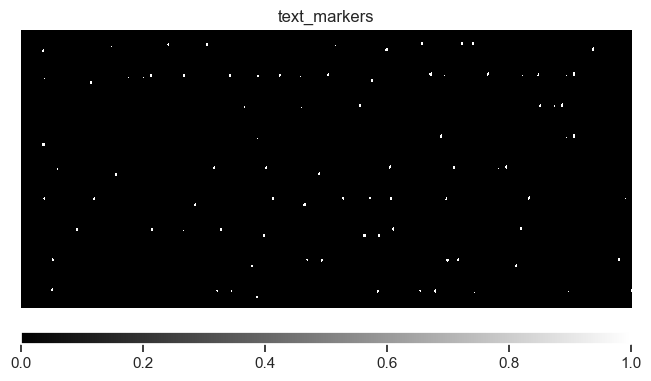

In [70]:
imshow_grid(text_markers=text_markers, interpolation='nearest', axis_off=True);

- Now we're going to dilate by reconstruction from the starting markers and condition on the original image.
- That way the dilated characters cannot "outgrow" their orginal shape.

In [71]:
text_rec_bw = bw_reconstruct_dilate(text_markers, text_bw, max_iters=100)
text_rec_bw.shape, text_rec_bw.dtype

((918, 2018), dtype('bool'))

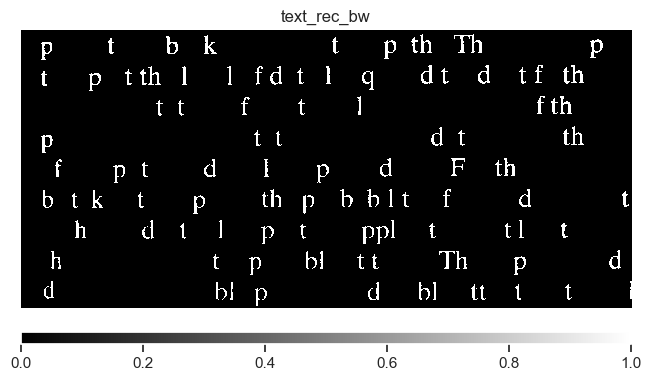

In [72]:
imshow_grid(text_rec_bw=text_rec_bw, interpolation='nearest', axis_off=True);

# Grayscale morphology

- Grayscale morphology is a *generalization* of binary morphology in which
  - both the image $I(m, n) \in \mathbb{R}$ and the structuring element $H(m, n) \in \mathbb{R}$ are real-valued functions,
  - and the binary set logic is replaced by the $\min$ and $\max$ operators.
- As a consequence, grayscale morphology can perform binary morphology, but not vice-versa.

## Grayscale dilation and erosion

**Dilation**
- Grayscale dilation is defined as  
  $$
  (I \oplus H)(m, n) = \max_{(i,j) \in H}\left( I(m-i, n-j) + H(i, j) \right)
  $$
- In other words,
  - we "slide" the SE over the image,
  - at each location we add pixels in local neighborhood whose shape is defined by the SE the image and the SE itself,
  - and then take the maximum of the result.
- Notice the minus sign in the $(i, j)$ coordinates, which mean the SE is *reflected* (flipped) around its origin. This is similar to e.g. convolution.

**Erosion**
- Grayscale erosion is defined as  
  $$
  (I \ominus H)(m, n) = \min_{(i,j) \in H}\left( I(m+i, n+j) - H(i,j) \right)
  $$
- In other words it's very similar to dilation, but  
  - we subtract instead of add,
  - we take $\min$ instead of $\max$,
  - and there is no flipping.

<figure class="image">
  <img src="../figures/morphology-grayscale_dilation_erosion.png" alt="" style="width: 12.8in; background: white"/>
  <figcaption>
    Grayscale dilation and erosion.<br>
    Source: [Burger22], Fig. 7.23 and 7.24
  </figcaption>
</figure>

**Properties**
- As in the binary case, grayscale dilation and erosion are duals w.r.t. complementation and reflection
  $$
  I \oplus H = \overline{\bar{I} \ominus H^*}
  $$
  where
  - $\overline{I(m, n)} = -I(m, n)$ is the complement operation,
  - $H^*(m, n) = H(-m, -n)$ is the reflection operation.
- It holds vice-versa as well  
  $$
  I \ominus H = \overline{\bar{I} \oplus H^*}
  $$

In [73]:
def dilate(
    gray: np.ndarray,
    strel: np.ndarray,
    origin: tuple[int, int] | None = None,
) -> np.ndarray:
    if origin is None:
        origin = (strel.shape[0] // 2, strel.shape[1] // 2)
    i0, j0 = origin
    gh, gw = gray.shape
    sh, sw = strel.shape

    # Reflect structuring element
    strel = np.flipud(np.fliplr(strel))
    i0, j0 = sh - 1 - i0, sw - 1 - j0
    mask = ~np.isnan(strel)

    # Pad image to handle borders
    gray = np.pad(gray, ((i0, sh - i0), (j0, sw - j0)), mode='edge')

    # Perform dilation
    dilated = np.zeros_like(gray)
    for i in range(gh):
        for j in range(gw):
            window = gray[i : i + sh, j : j + sw]
            dilated[i + i0, j + j0] = np.max(window[mask] + strel[mask])
    
    # Crop to original size
    dilated = dilated[i0 : i0 + gh, j0 : j0 + gw]

    return dilated

In [74]:
def erode(
    gray: np.ndarray,
    strel: np.ndarray,
    origin: tuple[int, int] | None = None,
) -> np.ndarray:
    if origin is None:
        origin = (strel.shape[0] // 2, strel.shape[1] // 2)
    i0, j0 = origin
    gh, gw = gray.shape
    sh, sw = strel.shape

    # No reflection for erosion
    mask = ~np.isnan(strel)

    # Pad image to handle borders
    gray = np.pad(gray, ((i0, sh - i0), (j0, sw - j0)), mode='edge')

    # Perform erosion
    eroded = np.zeros_like(gray)
    for i in range(gh):
        for j in range(gw):
            window = gray[i : i + sh, j : j + sw]
            eroded[i + i0, j + j0] = np.min(window[mask] - strel[mask])
    
    # Crop to original size
    eroded = eroded[i0 : i0 + gh, j0 : j0 + gw]

    return eroded

In [75]:
strel_gray = disk(3) / 255.0
strel_gray[strel_gray == 0] = np.nan
strel_gray

array([[  nan, 0.004,   nan],
       [0.004, 0.004, 0.004],
       [  nan, 0.004,   nan]])

In [76]:
rice_dil_gray = dilate(rice_gray, strel_gray)
rice_dil_gray.shape, rice_dil_gray.dtype, rice_dil_gray.min(), rice_dil_gray.max()

((256, 256),
 dtype('float64'),
 np.float64(0.16862745098039217),
 np.float64(0.8392156862745098))

In [77]:
rice_ero_gray = erode(rice_gray, strel_gray)
rice_ero_gray.shape, rice_ero_gray.dtype, rice_ero_gray.min(), rice_ero_gray.max()

((256, 256),
 dtype('float64'),
 np.float64(0.09411764705882351),
 np.float64(0.788235294117647))

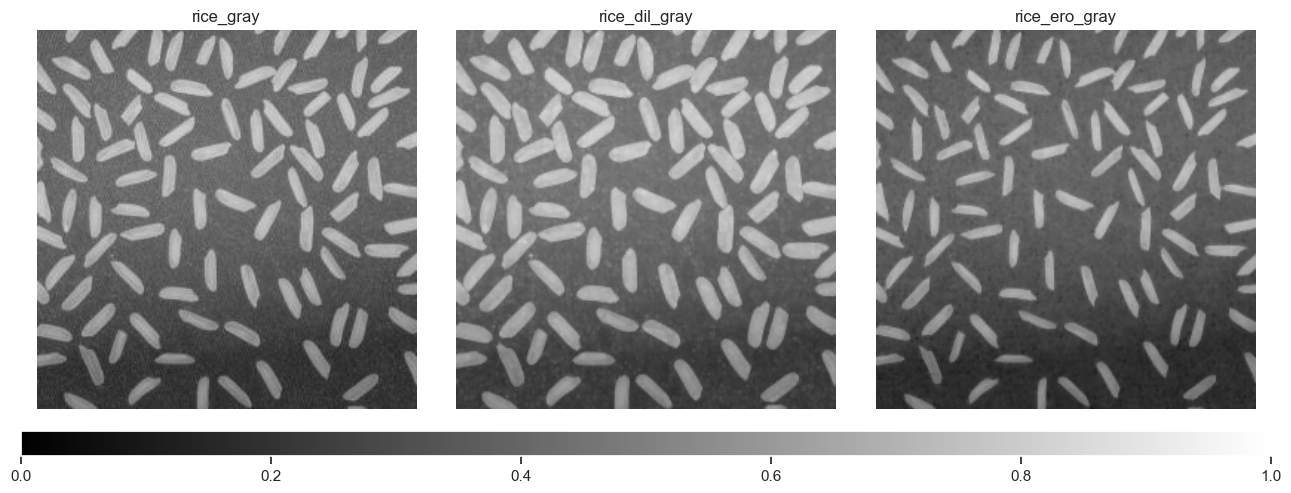

In [78]:
imshow_grid(rice_gray=rice_gray, rice_dil_gray=rice_dil_gray, rice_ero_gray=rice_ero_gray);

### Grayscale morphology applied on binary images

- Grayscale morphology works on binary images as well.
- This along with efficiency of set operations is the reason why real world implementations such as scikit-image or OpenCV don't actually work with sets, but perform the two fundamental operations dilation and erosion as simple local min/max.
- Binary morphology is nevertheless still useful for building theoretical foundation and intuition.

In [79]:
# Apply grayscale erosion on binary image converted to float
rice_bw_ero_gray = erode(rice_bw.astype(float), strel_gray)
rice_bw_ero_gray.shape, rice_bw_ero_gray.dtype, rice_bw_ero_gray.min(), rice_bw_ero_gray.max()

((256, 256),
 dtype('float64'),
 np.float64(-0.00392156862745098),
 np.float64(0.996078431372549))

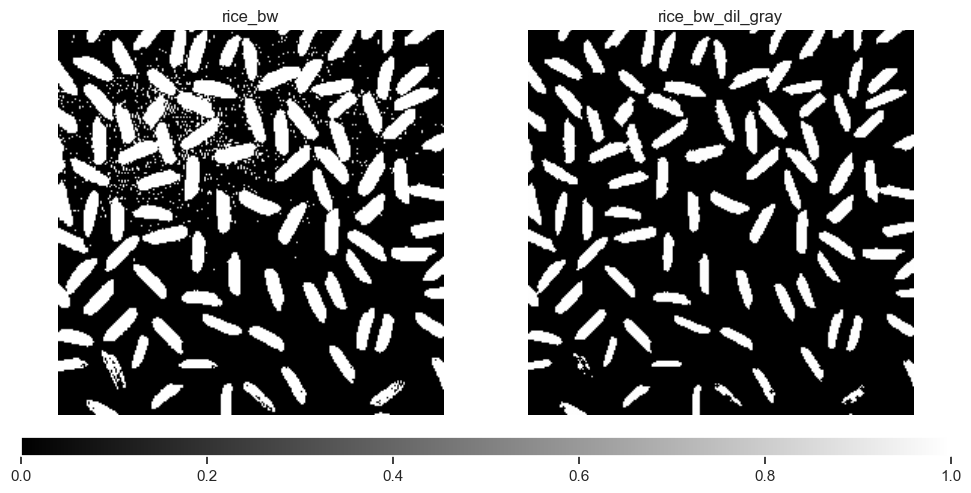

In [80]:
imshow_grid(rice_bw=rice_bw, rice_bw_dil_gray=rice_bw_ero_gray, vmax=1.0);

### Morphological gradient

- Morphological gradient is defined as dilation minus erosion, i.e.  
  $$
  G(I) = (I \oplus H) - (I \ominus H)
  $$
- It is useful for edge detection and image segmentation.

In [81]:
rice_grad_gray = rice_dil_gray - rice_ero_gray
rice_grad_gray.shape, rice_grad_gray.dtype, rice_grad_gray.min(), rice_grad_gray.max

((256, 256),
 dtype('float64'),
 np.float64(0.007843137254901933),
 <function ndarray.max>)

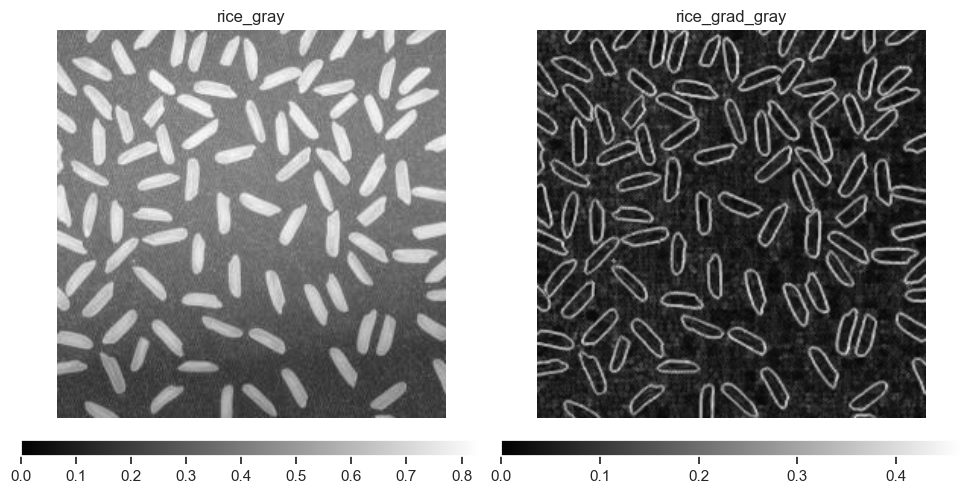

In [82]:
imshow_grid(rice_gray=rice_gray, rice_grad_gray=rice_grad_gray, vmax='max', interpolation='bilinear');

## Grayscale closing and opening

- Grayscale closing and opening definitions are the same as their binary counterparts, that is  
  grayscale closing is grayscale dilation followed by grayscale erosion  
  $$
  I \bullet H = (I \oplus H) \ominus H
  $$  
  and grayscale opening is grayscale erosion followed by grayscale dilation  
  $$
  I \circ H = (I \ominus H) \oplus H
  $$

In [83]:
def close(
    gray: np.ndarray,
    strel: np.ndarray,
    origin: tuple[int, int] | None = None,
) -> np.ndarray:
    dilated = dilate(gray, strel, origin=origin)
    closed = erode(dilated, strel, origin=origin)
    return closed

In [84]:
def open(
    gray: np.ndarray,
    strel: np.ndarray,
    origin: tuple[int, int] | None = None,
) -> np.ndarray:
    eroded = erode(gray, strel, origin=origin)
    opened = dilate(eroded, strel, origin=origin)
    return opened

In [85]:
rice_sp_gray = skimage.util.random_noise(rice_gray, mode='s&p', amount=0.03)
rice_sp_gray.shape, rice_sp_gray.dtype, rice_sp_gray.min(), rice_sp_gray.max()

((256, 256), dtype('float64'), np.float64(0.0), np.float64(1.0))

In [86]:
rice_sp_clo_gray = close(rice_sp_gray, strel_gray)
rice_sp_clo_gray.shape, rice_sp_clo_gray.dtype, rice_sp_clo_gray.min(), rice_sp_clo_gray.max()

((256, 256), dtype('float64'), np.float64(0.1647058823529412), np.float64(1.0))

In [87]:
rice_sp_opn_gray = open(rice_sp_gray, strel_gray)
rice_sp_opn_gray.shape, rice_sp_opn_gray.dtype, rice_sp_opn_gray.min(), rice_sp_opn_gray.max()

((256, 256), dtype('float64'), np.float64(0.0), np.float64(0.788235294117647))

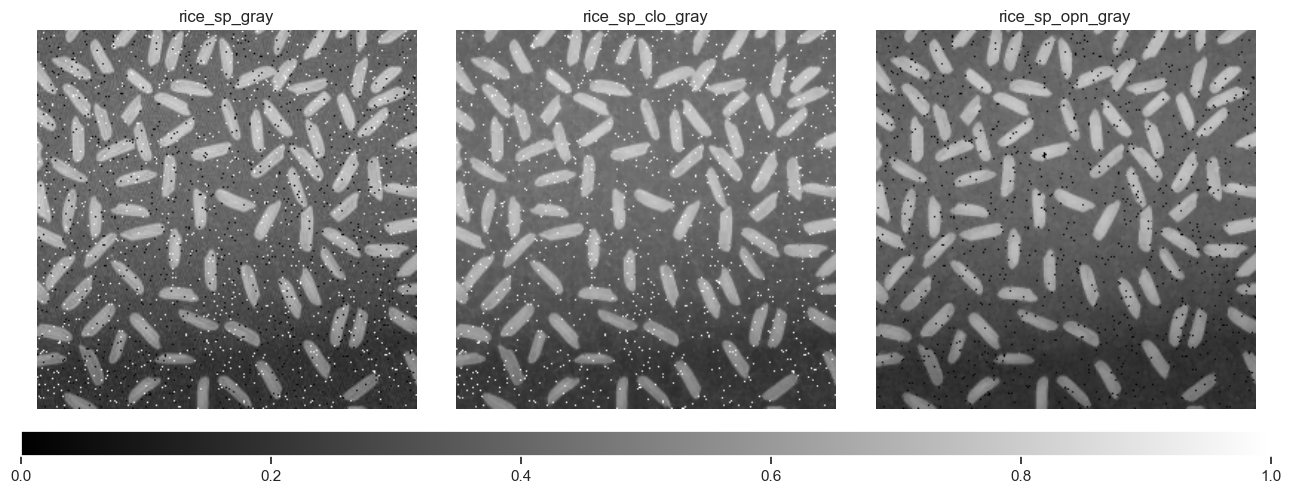

In [88]:
imshow_grid(rice_sp_gray=rice_sp_gray, rice_sp_clo_gray=rice_sp_clo_gray, rice_sp_opn_gray=rice_sp_opn_gray);

### Morphological smoothing

- Closing and opening are useful e.g. for smoothing, especially "spiky" noise like salt & pepper.
- The local $\max$ operation closes dark spots (but also increases overall brightness) while the local $\min$ cuts out bright spots (but also decreases overall brightness).
- Their successive application therefore cleans both types of noise and simultaneously cancels out the brightness change effects.
- Thanks to $\max$ and $\min$ being non-linear, morphological smoothing can preserve edges.
- Of course all depends on the right selection of the strcuturing element.

In [89]:
rice_sp_clean_gray = open(close(rice_sp_gray, strel_gray), strel_gray)
rice_sp_clean_gray.shape, rice_sp_clean_gray.dtype, rice_sp_clean_gray.min(), rice_sp_clean_gray.max()

((256, 256),
 dtype('float64'),
 np.float64(0.1647058823529412),
 np.float64(0.807843137254902))

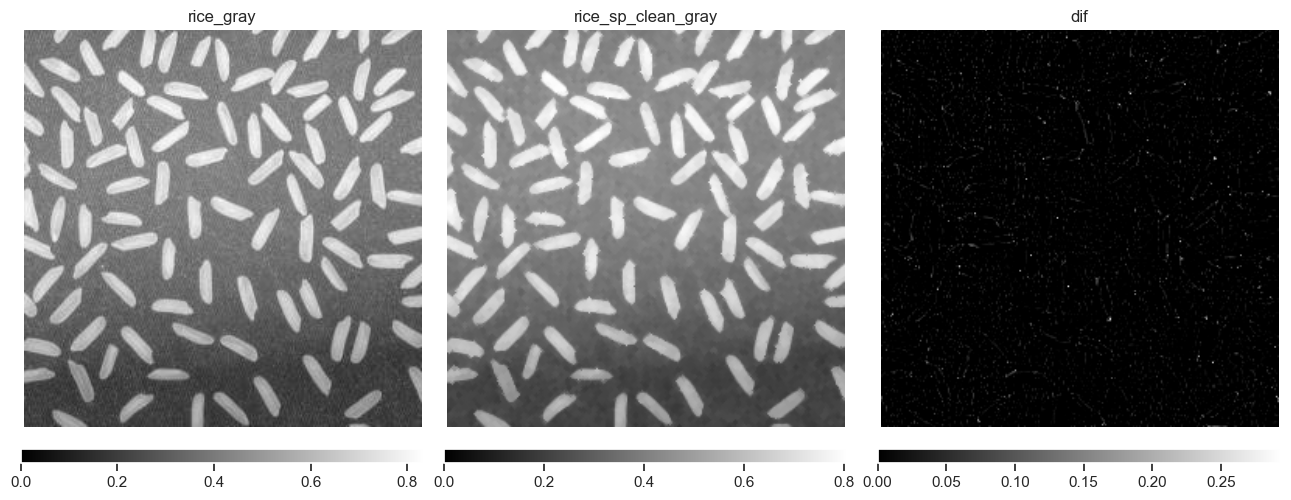

In [90]:
imshow_grid(rice_gray=rice_gray, rice_sp_clean_gray=rice_sp_clean_gray, dif=rice_gray - rice_sp_clean_gray, vmax='max', interpolation='bilinear');

## Top-hat and bottom-hat transformations

- Let's say we want to extract the rice grains.
- As we already saw, simple thresholding does not work very well, mostly because of the non-uniform lighting.
- Simply put rice grains in the bottom are darker than the background in the upper portion of the image.
- As we just saw above, opening removes "tips" of objects that are smaller than the SE.
- On the other, objects and structures that are larger than the SE are ideally left untouched.
- If the small "tips" are actually the objects of interest (for example the rice grains above), we can extract them by simply taking the difference between the original image and the opened one.
- Such composite operation has its own name nad is called **top-hat transformation**, i.e.  
  $$
  T_{\text{t}} = I - (I \circ H)
  $$
- In other words, we remove the non-uniform background by subtraction.
- The opposite operation, i.e. extraction of "dips", is called **bottom-hat transformation**, and is defined as closed minus original  
  $$
  T_{\text{t}} = (I \bullet H) - I
  $$

In [91]:
def tophat(
    gray: np.ndarray,
    strel: np.ndarray,
    origin: tuple[int, int] | None = None,
) -> np.ndarray:
    opened = open(gray, strel, origin=origin)
    tophat = gray - opened
    return tophat

In [92]:
rice_strel_gray = disk(15) / 255.0  # should be large enough to cover rice grains
rice_strel_gray[rice_strel_gray == 0] = np.nan  # add don't care pixels
rice_tophat_gray = tophat(rice_gray, rice_strel_gray)
rice_tophat_gray.shape, rice_tophat_gray.dtype, rice_tophat_gray.min(), rice_tophat_gray.max()

((256, 256), dtype('float64'), np.float64(0.0), np.float64(0.4588235294117647))

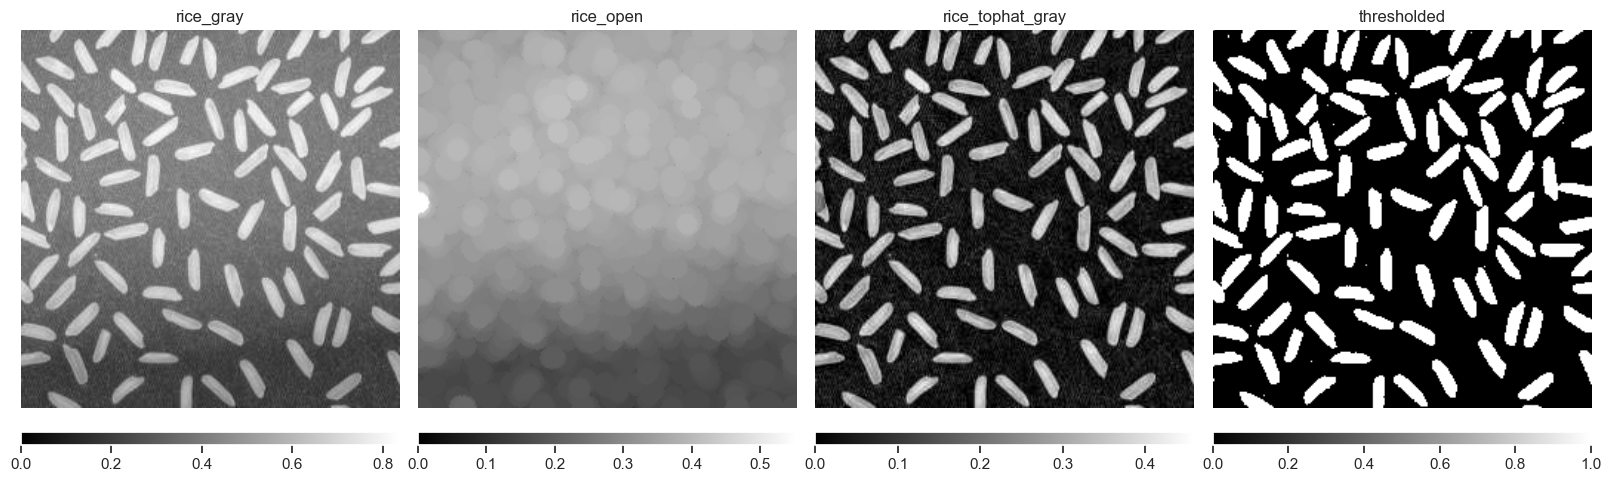

In [93]:
imshow_grid(
    rice_gray=rice_gray,
    rice_open=open(rice_gray, rice_strel_gray),
    rice_tophat_gray=rice_tophat_gray,
    thresholded=rice_tophat_gray > 0.15,
    vmax='max',
);

## Granulometry

- Granulometry in is a technique used to analyze the size distribution of structures (grains) in an image.
- In mathematical morphology, the particle size distribution (PSD) can be estimated *without having to measure individual particles*.
- The apporoach is based on **progressive application of opening (or dilation)** and **counting the remaining pixels**, i.e.  
  $$
  G(d) = \frac{ \sum_{i,j}{I} - \sum_{i,j}{ (I \circ H_d)} }{ \sum_{i,j} I }
  $$
  where
  - $d$ is the size of the structuring element $H$.
- The idea is that when the SE becomes larger than some object in the image, lots of pixels will get "attenuated" by the opening and thus there will be a sharp decline in the overall image sum.
- We can then calculate the particle size distribution (i.e. histogram of particle sizes) as  
  $$
  D(d) = G(d) - G(d - 1)
  $$

In [94]:
def granulometry_curve(gray: np.ndarray, max_size: int = 0) -> tuple[np.ndarray, np.ndarray]:
    if max_size <= 0:
        max_size = min(gray.shape)
    sizes, sums = [1], [gray.sum()]
    for diameter in range(3, max_size + 1, 2):
        strel = disk(diameter) / 255.0
        strel[strel == 0] = np.nan  # add don't care pixels
        opened = open(gray, strel)
        sizes.append(diameter)
        sums.append(opened.sum())
    sizes = np.array(sizes)
    sums = np.array(sums) / sums[0]
    return sizes, sums

In [95]:
# Takes a while to compute
rice_sizes, rice_cpsd = granulometry_curve(rice_gray, max_size=31)
rice_sizes, rice_cpsd

(array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31]),
 array([1.   , 0.971, 0.95 , 0.926, 0.869, 0.76 , 0.732, 0.72 , 0.71 , 0.701, 0.695, 0.692, 0.688, 0.685, 0.681, 0.679]))

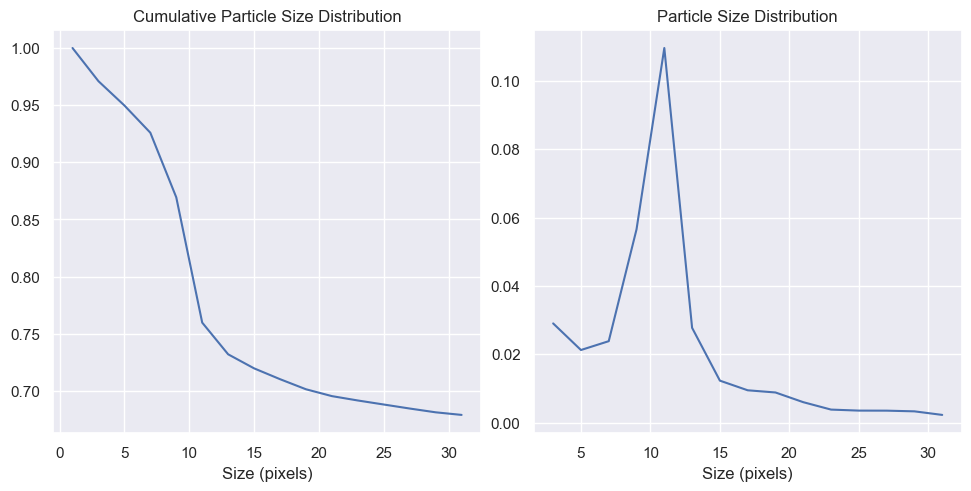

In [96]:
fig, axes = plt.subplots(1, 2, figsize=plt.figaspect(0.5))
axes[0].plot(rice_sizes, rice_cpsd)
axes[0].set_title('Cumulative Particle Size Distribution');
axes[0].set_xlabel('Size (pixels)');
axes[1].plot(rice_sizes[1:], (rice_cpsd[:-1] - rice_cpsd[1:]), '-');
axes[1].set_title('Particle Size Distribution');
axes[1].set_xlabel('Size (pixels)');

## Grayscale morphological reconstruction

- Grayscale morphological reconstruction is very similar to the binary case
- We again have marker image and a mask image and we iteratively reconstruct the marker under conditions imposed by the mask.
- For example, *one iteration* of **grayscale geodesic dilation by reconstruction** is defined as  
  $$
  I_{t+1} = (I_{t} \oplus H) \cap X
  $$
  where
  - $I_t$ is the marker,
  - $X$ is the mask,
  - $\cap$ denotes point-wise minimum operator (which corresponds to set intersection when treating grayscale images as sets of points in 3D).
- In case or **grayscale geodesic erosion by reconstruction** the rule is  
  $$
  I_{t+1} = (I_{t} \ominus H) \cup X
  $$
  where
  - $\cup$ denotes point-wise maximum operator.
- As in the binary case, the grayscale **closing** and **opening** start with one or few iterations of dilation and erosion, respectively, and then perform the dual operation iteratively to reconstruct.